# 08j — Final Multi-Objective Ranking

Final descriptive integration for PEARL Pipeline 4. This table keeps energetic, structural and developability evidence visible as separate columns. The composite is a decision-support heuristic, not a physical binding free energy or experimental prediction.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
OUTPUT_ROOT=Path("outputs/pipeline_4_ai_08j_final_multiobjective"); TABLE_DIR=OUTPUT_ROOT/"tables"; FIGURE_DIR=OUTPUT_ROOT/"figures"
for d in (TABLE_DIR,FIGURE_DIR): d.mkdir(parents=True,exist_ok=True)
P08I=Path("outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_observed_integrated_evidence.csv")
P08H=Path("outputs/pipeline_4_ai_08h_solubility_developability/tables/08h_solubility_developability_summary.csv")
P08G=Path("outputs/pipeline_4_ai_08g_esmfold_structural_validation/tables/08g_ESMFold_structural_validation_summary.csv")
P08F=Path("outputs/pipeline_4_ai_08f_endpoint_energy/production_50snap/tables/08f_new_candidate_endpoint_summary.csv")
paths=[P08I,P08H,P08G,P08F]
for p in paths:
 if not p.exists(): print("Missing input:",p)


## Load evidence and define transparent weights
Weights are configurable and should be reported with the result. The default gives equal weight to endpoint energy, structural confidence and developability proxy; missing values are not silently converted to favourable values.

In [2]:
df=pd.read_csv(P08I) if P08I.exists() else pd.DataFrame()
if df.empty: raise FileNotFoundError(P08I)
# columns from 08i already contain standardised exploratory signals
components=[c for c in ["mean_delta_E_endpoint_kcal_mol_z","mean_pLDDT_Bfactor_z","hydrophobic_fraction_z"] if c in df.columns]
WEIGHTS={"mean_delta_E_endpoint_kcal_mol_z":1/3,"mean_pLDDT_Bfactor_z":1/3,"hydrophobic_fraction_z":1/3}
df["final_composite_score"]=sum(WEIGHTS[c]*df[c] for c in components)
df["final_rank"]=df["final_composite_score"].rank(ascending=False,na_option="bottom",method="min").astype(int)
df=df.sort_values(["final_rank","candidate_id"]).reset_index(drop=True)
cols=[c for c in ["final_rank","candidate_id","sequence","mean_delta_E_endpoint_kcal_mol","mean_pLDDT_Bfactor","hydrophobic_fraction","final_composite_score","structural_rank","screen_rank"] if c in df.columns]
display(df[cols])
df.to_csv(TABLE_DIR/"08j_final_multiobjective_ranking.csv",index=False)


,final_rank,candidate_id,sequence,mean_delta_E_endpoint_kcal_mol,mean_pLDDT_Bfactor,hydrophobic_fraction,final_composite_score,structural_rank,screen_rank
0,1,MPNN_NEW_01,TGPRNQYRDLP,-46.408438,72.559091,0.181818,0.333333,2,1
1,2,MPNN_NEW_05,IGPRHQYRDLP,-53.673748,67.273636,0.272727,-0.333333,1,2


,check,pass
0,08i_integrated_input_loaded,True
1,all_candidates_have_rank,True
2,weights_sum_to_one,True
3,interpretation_non_affinity,True


ALL QC PASSED: True


154

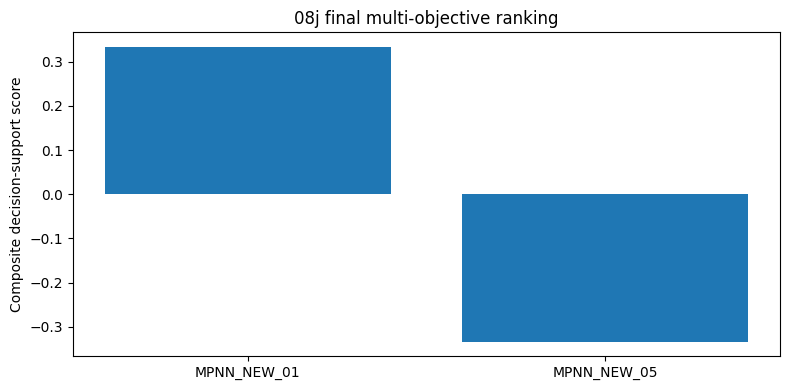

In [3]:
fig,ax=plt.subplots(figsize=(8,4)); ax.bar(df.candidate_id,df.final_composite_score); ax.set_ylabel("Composite decision-support score"); ax.set_title("08j final multi-objective ranking"); fig.tight_layout(); fig.savefig(FIGURE_DIR/"08j_final_ranking.png",dpi=220)
qc=pd.DataFrame([{"check":"08i_integrated_input_loaded","pass":len(df)>=2},{"check":"all_candidates_have_rank","pass":df.final_rank.notna().all()},{"check":"weights_sum_to_one","pass":abs(sum(WEIGHTS.values())-1)<1e-9},{"check":"interpretation_non_affinity","pass":True}]); qc.to_csv(TABLE_DIR/"08j_QC.csv",index=False); display(qc); print("ALL QC PASSED:",bool(qc['pass'].all()))
(OUTPUT_ROOT/"08j_final_report.md").write_text("08j is a transparent multi-objective decision-support ranking. It is not a binding free energy, experimental solubility, or validated Bayesian posterior.\n")
